In [7]:
from aqua.util import load_yaml
import matplotlib.pyplot as plt

In [2]:
res = load_yaml('regrid_comparison_results.yaml')

In [14]:
# Build the list of values

AQUA_dict = {1: None, 2: None, 4: None, 8: None, 16: None, 32: None}
for key, value in res.items():
    if key.startswith('AQUA'):
        AQUA_dict[int(key.split('_')[1])] = value['total_time']

CDO_value = res['CDO']['total_time']

In [12]:
# Normalize the values, store the speedup relative to the 1 process case
AQUA_norm = {k: AQUA_dict[1] / v for k, v in AQUA_dict.items() if v is not None}
AQUA_norm

{1: 1.0,
 2: 0.9829455131536753,
 4: 1.65092478122135,
 8: 2.6032012033603773,
 16: 3.750250441589024,
 32: 4.512439608382191,
 64: 3.6167725274961176}

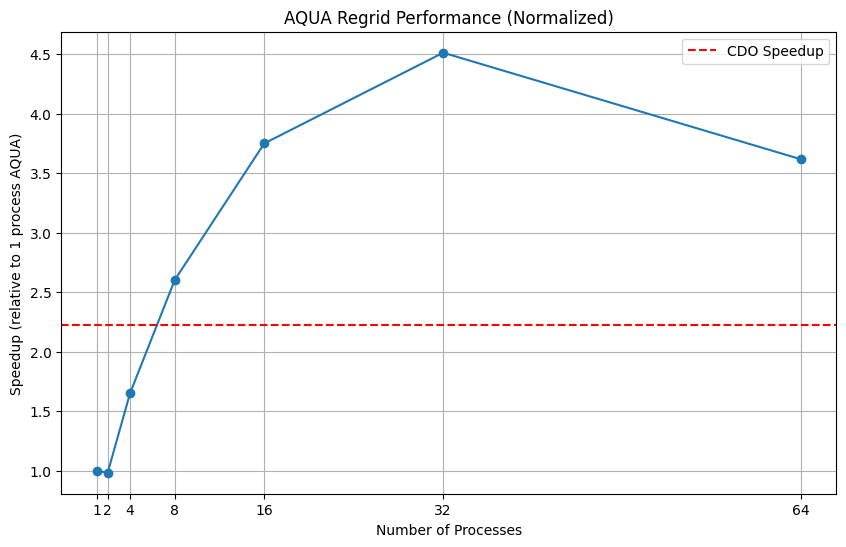

In [16]:
# Plot the normalized values
plt.figure(figsize=(10, 6))
plt.plot(list(AQUA_norm.keys()), list(AQUA_norm.values()), marker='o')
plt.title('AQUA Regrid Performance (Normalized)')
plt.xlabel('Number of Processes')
plt.ylabel('Speedup (relative to 1 process AQUA)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)

# Add CDO value for comparison
if CDO_value is not None:
    plt.axhline(y=AQUA_dict[1] / CDO_value, color='r', linestyle='--', label='CDO Speedup')
    plt.legend()
plt.show()